# Chatbot with Profile Schema
## Review
We introduced the LangGraph Memory Store (`memory_store.ipynb`) as a way to save and retrieve long-term memories.

It saved long-term semantic memory in the hot path, as the user is chatting with it.

## Goals
Our chatbot saved memories as a string. In practice, we often want memories to have a structure. For example, memories can be a single, continuously updated schema. In our case, we want this to be a single user profile.

We'll extend our chatbot to save semantic memories to a single user profile. We'll also introduce a library, Trustcall, to update this schema with new information.

## Defining a User Profile Schema
Python has many different types for structured data, such as TypedDict, Dictionaries, JSON, and Pydantic.

Let's use TypedDict to define a user profile schema.

## Saving a Schema to the Store
The LangGraph Store accepts any Python dictionary as the `value`.

In [2]:
import os
import re 
import uuid
import json
from dotenv import load_dotenv
from typing import TypedDict, List
from pydantic import BaseModel, Field

from IPython.display import Image, display
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.base import BaseStore

from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig

# Load env variable for API Key
load_dotenv()
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL")

# Set the Chat Model
model = ChatOpenAI(
    model="deepseek-chat",  # Or "deepseek-v4-flash" for a faster option
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    temperature=0,
    #extra_body={"enable_thinking": False}
)

class UserProfile(BaseModel):
    """
    User profile schema with typed fields.
    """
    user_name: str
    interests: List[str]

user_profile: UserProfile = {
    "user_name": "Lance",
    "interests": ["biking", "technology", "coffee"]
}

# Initialize the in-memory store
in_memory_store = InMemoryStore()

user_id = "1"
namespace_for_memory = (user_id, "memory")

# Save a memory to namespace as key and value
key = "user_profile"
value = user_profile
in_memory_store.put(namespace_for_memory, key, value)

# Search
for m in in_memory_store.search(namespace_for_memory):
    print(m.dict())

{'namespace': ['1', 'memory'], 'key': 'user_profile', 'value': {'user_name': 'Lance', 'interests': ['biking', 'technology', 'coffee']}, 'created_at': '2026-07-22T01:35:36.497185+00:00', 'updated_at': '2026-07-22T01:35:36.497194+00:00', 'score': None}


## Chatbot with Profile Schema
Now we know how to specify a schema for the memories and save it to the store. How do we actually create memories with this particular schema?

In our chatbot, we want to create memories from a user chat. This is where the concept of structured outputs is useful.

In [3]:
from typing import Type, TypeVar, Optional

T = TypeVar("T", bound=BaseModel)

def get_structured_response_native(llm, output_class: Type[T], system_message, prompt):
    """
    Use DeepSeek's native response format.
    """
    schema = output_class.model_json_schema()
    system_messages = SystemMessage(
        content=system_message + 
        f"""
            You are a helpful assistant that always responds in JSON format.
            The response must match this JSON schema: {json.dumps(schema, indent=2)}

            Do not include any other text, explanation, or markdown formatting.
            Only respond with valid JSON that matches the schema.
        """
    )
    human_message = HumanMessage(content=prompt)
    response = llm.invoke([system_messages, human_message])
    content = response.content
    content = re.sub(r'```json\s*|```\s*', '', content)
    data = json.loads(content)
    return output_class(**data)

structured_output = get_structured_response_native(model, UserProfile, "", "My name is Lance, I like to bike.")
print(structured_output)

user_name='Lance' interests=['biking']


Now, let's use this with our chatbot. This only requires minor changes to the `write_memory` function. We use `model_with_structure` to produce a profile that matches our schema.

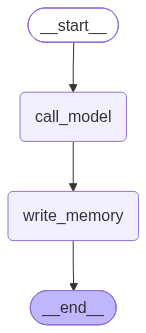

================================ Human Message =================================

Hi, my name is Lance and I like to bike around San Francisco and eat at bakeries.
================================== Ai Message ==================================

Nice to meet you, Lance! That sounds like a fantastic way to explore San Francisco—biking through the hills and stopping at bakeries along the way. Do you have a favorite route or bakery you’ve discovered so far?


In [4]:
# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """
    You are a helpful assistant with memory that provides information about the user.
    If you have memory for this user, use it to personalize your responses. Here is the
    memory (it may be empty): {memory}.
"""

# Create new memory from the chat history and any existing memory
CREATE_MEMORY_INSTRUCTION = """
    Create or update a user profile memory based on the user's chat history.
    This will be saved for long-term memory. If there is an existing memory, simply update it.
    Here is the existing memory (it may be empty): {memory}.
"""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """
    Load memory from the store and use it to personalize the chatbot's response.
    """
    user_id = config["configurable"]["user_id"]
    
    # Retrieve memory from the store
    namespace = ("memory", user_id)
    key = "user_memory"
    existing_memory = store.get(namespace, key)

    if existing_memory and existing_memory.value:
        memory_dict = existing_memory.value
        formatted_memory = (
            f"Name: {memory_dict.get("user_name", "Unknown")}\n"
            f"Interests: {', '.join(memory_dict.get("interests", []))}"
        )
    else:
        formatted_memory = None
        
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=formatted_memory)
    response = model.invoke([SystemMessage(content=system_msg)] + state["messages"])
    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """
    Reflect on the chat history and save a memory to the store.
    """
    user_id = config["configurable"]["user_id"]
    
    # Retrieve memory from the store
    namespace = ("memory", user_id)
    key = "user_memory"
    existing_memory = store.get(namespace, key)
    
    if existing_memory and existing_memory.value:
        memory_dict = existing_memory.value
        formatted_memory = (
            f"Name: {memory_dict.get("user_name", "Unknown")}\n"
            f"Interests: {', '.join(memory_dict.get("interests", []))}"
        )
    else:
        formatted_memory = None

    system_msg = CREATE_MEMORY_INSTRUCTION.format(memory=formatted_memory)
    new_memory = model.invoke([SystemMessage(content=system_msg)] + state["messages"])
    
    # Overwrite the existing memory in the store
    store.put(namespace, key, {"memory": new_memory.content})

# Build the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Store for long-term memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term memory
within_thread_memory = MemorySaver()

graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)
display(Image(graph.get_graph().draw_mermaid_png()))

# We supply a thread ID for short-term memory, a user ID for long-term memory
config = {"configurable": {"thread_id": "1", "user_id": "1"}}
input_messages = [HumanMessage(content="Hi, my name is Lance and I like to bike around San Francisco and eat at bakeries.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()


## Trustcall for Creating and Updating Profile Schema
As we can see, working with schemas can be tricky. Complex schemas can be difficult to extract. In addition, updating even simple schemas can pose challenges.

Consider our above chatbot. We regenerated the profile schema from scratch each time we chose to save a new memory. This is inefficient, potentially wasting model tokens if the schema contains a lot of information to regenerate each time.

Addressing these problems is the motivation for TrustCall. This is an open-source library for updating JSON schemas developed by LangChain team.

We use `create_extractor`, passing in the model as well as our schema as a tool. With TrustCall, can supply the schema in various ways. Under the hood, TrustCall uses tool_calling to produce structured output from an input list of messages.

To force TrustCall to produce structured output, we can include the schema name in the `tool_choice` argument. We can invoke the extractor with the above conversation.

In [5]:
from trustcall import create_extractor

# Create conversation
conversation = [
    HumanMessage(content="Hi, I'm Lance."),
    AIMessage(content="Nice to meet you, Lance."),
    HumanMessage(content="I really like biking around San Francisco.")
]

class UserProfile(BaseModel):
    """
    User Profile schema with typed fields.
    """
    user_name: str = Field(description="The user's preferred name.")
    interests: List[str] = Field(description="A list of the user's interests.")

trustcall_extractor = create_extractor(
    model,
    tools=[UserProfile],
    tool_choice="UserProfile"
)

# Instruction
system_msg = "Extract the user profile from the following conversation."
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=system_msg)] + conversation})

for m in result["messages"]:
    m.pretty_print()

schema = result["responses"]

================================== Ai Message ==================================
Tool Calls:
  UserProfile (call_00_fLNREeIY0OF1yr9POj8F5863)
 Call ID: call_00_fLNREeIY0OF1yr9POj8F5863
  Args:
    user_name: Lance
    interests: ['biking', 'San Francisco']


Let's see how we can use it to update the profile. For updating, TrustCall takes a set of messages as well as the existing schema. The central idea is that it prompts the model to produce a JSON Patch to update only the relevant parts of the schema.

It's also more efficient since the model only needs to generate the parts of the schema that have changed. We can save the existing schema as a dict. We can use `model_dump()` to serialize a Pydantic model instance into a dict. We pass it to the `existing` argument along with the schema name `UserProfile`.

In [6]:
updated_conversation = [
    HumanMessage(content="Hi, I'm Lance."), 
    AIMessage(content="Nice to meet you, Lance."), 
    HumanMessage(content="I really like biking around San Francisco."),
    AIMessage(content="San Francisco is a great city! Where do you go after biking?"),
    HumanMessage(content="I really like to go to a bakery after biking."),
]

# Update the instruction
system_msg = f"""
    Update the memory (JSON doc) to incorporate new information from the following conversation.
"""
result = trustcall_extractor.invoke(
    {"messages": [SystemMessage(content=system_msg)] + updated_conversation},
    config={"existing": {"UserProfile": schema[0].model_dump()}}
)

for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  UserProfile (call_00_0eEI7JVzJLwqAIA2ulbY9209)
 Call ID: call_00_0eEI7JVzJLwqAIA2ulbY9209
  Args:
    user_name: Lance
    interests: ['biking', 'bakeries']
